# Part 2 - Model Training (Processed Data) with PyTorch

In this part we create and train a neural network model using **PyTorch 2.x**.
This version uses preprocessed RGB data from `.npy` files.

## Key Differences from Other Training Notebooks

- Uses raw preprocessed `.npy` files directly
- Includes data cleaning and balancing procedures
- Supports multiple training approaches

## Migration Notes

This notebook has been migrated from TensorFlow/TFLearn to PyTorch. Key changes:
- `googlenet` replaced with `get_model()` from `models_pytorch.py`
- `model.fit()` replaced with PyTorch training loop
- `model.save()/load()` replaced with `save_model()/load_model()`

## Loding Libraries
Here we load the common libraries

In [ ]:
# Standard libraries
import numpy as np
import cv2
import os
import pandas as pd
from pathlib import Path
from collections import deque
from random import shuffle
import matplotlib.pyplot as plt
import logging, sys
logging.disable(sys.maxsize)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Sklearn
from sklearn.model_selection import train_test_split

# Local imports - PyTorch models
from models_pytorch import (
    get_model, list_models, get_model_info, 
    save_model, load_model, count_parameters, get_device
)

# Check PyTorch version and device
print(f"PyTorch Version: {torch.__version__}")
device = get_device()
print(f"Using device: {device}")

# Cleaning of the Input file
We are going to analize the files and clean  that we have created in the part 1
Let us first select the first created file.

In [2]:
#Preprocessed image rgb color - no image filters
file_name = "preprocessed_training_data-1.npy"
#file_name = "training_data-1.npy"

In [3]:
# full file info
train_data = np.load(file_name,allow_pickle=True)

In [4]:
# This file has the following shape
train_data.shape
#(500, 2)

(500, 2)

There are 29 input componentes for each frame, we can plot the histogram for each component

In [5]:
train_hist = train_data[:]

In [6]:
train_hist.shape

(500, 2)

In [7]:
df = pd.DataFrame()
for i in range(len(train_hist)):
    row=list(train_hist[i][1])
    #print(row)
    temp = pd.DataFrame([row])
   # print(temp)
    df = pd.concat([df, temp])
df=df.reset_index(drop=True)  

In [8]:
#We count rows different to zero
(df[13] != 0).astype(int).sum(axis=0)


27

In [9]:
threshold= (df[13] != 0).astype(int).sum(axis=0)

In [10]:
print(threshold) # We assume that is different to zero

27


In [11]:
num_bins = 25
samples_per_bin = threshold
hist, bins = np.histogram(df[13], num_bins)
center = (bins[:-1]+ bins[1:]) * 0.5

total data: 500


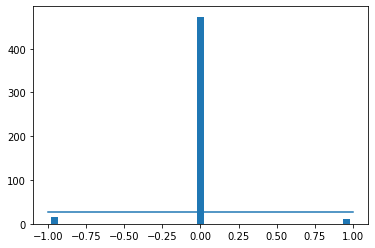

In [12]:
plt.bar(center, hist, width=0.05)
plt.plot((np.min(df[13]), np.max(df[13])), (samples_per_bin, samples_per_bin))
print('total data:', len(df[13]))

In [13]:
remove_list = []
for j in range(num_bins):
    list_ = []
    for i in range(len(df[13])):
        serie=df[13].iloc[[i]]
        ls = serie.tolist()
        if ls[0] >= bins[j] and ls[0] <= bins[j+1]:
            list_.append(i)      
    #list_ = shuffle(list_)
    list_ = list_[samples_per_bin:]
    remove_list.extend(list_)

In [14]:
print('removed:', len(remove_list))

removed: 446


In [15]:
df_removed=df.drop(remove_list, axis=0, inplace=False)

In [16]:
#We count rows different to zero
(df_removed[13] != 0).astype(int).sum(axis=0)

27

In [17]:
df.drop(df.index[remove_list], inplace=True)

print('remaining:', len(df))

remaining: 54


In [18]:
df=df.reset_index(drop=True) # We reset the index ! attention

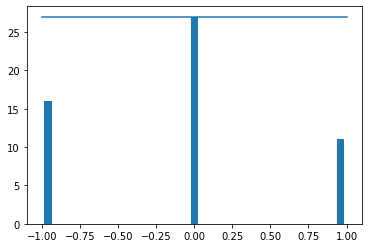

In [19]:
hist, _ = np.histogram(df[13], (num_bins))
plt.bar(center, hist, width=0.05)
plt.plot((np.min(df[13]), np.max(df[13])), (samples_per_bin, samples_per_bin))

we can create the function that convert the dataframe row to numpy image array

In [20]:
def df_to_numpy_image(df_image_clean,index):
    #select the row with index label 'index'
    image_clean=df_image_clean.loc[[index]].T.to_numpy()
    lists =image_clean.tolist()
    # Nested List Comprehension to flatten a given 2-D matrix
    # 2-D List
    matrix = lists
    flatten_matrix = [val.tolist() for sublist in matrix for val in sublist]
    # converting list to array
    arr = np.array(flatten_matrix)
    return arr

In [21]:
df_image = pd.DataFrame()
for i in range(len(train_hist)):
    row=list(train_hist[i][0]) # For images  Here we lost the (i, 480, 3) shape
    #print(row)    
    temp = pd.DataFrame([row])
   # print(temp)
    df_image = pd.concat([df_image, temp])
df_image=df_image.reset_index(drop=True)
df_image_removed=df_image.drop(remove_list, axis=0, inplace=False)
df_image_clean=df_image_removed.reset_index(drop=True)
df_image_clean.shape

(54, 270)

In [25]:
image1=df_to_numpy_image(df_image_clean,50)


In [26]:
image1.shape

(270, 480, 3)

## Creation of train and test split

In [27]:
#We verify that the dimensions are the same
assert len(df) == len(df_image_clean), "The dimensions are not equal, something is wrong "

In [28]:
#train = train_data[:-50]
#test = train_data[-50:]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_valid, y_train, y_valid = train_test_split(df_image_clean, df, test_size=0.2, random_state=6)

In [31]:
print('Training Samples: {}\nValid Samples: {}'.format(len(X_train), len(y_valid)))

Training Samples: 43
Valid Samples: 11


Text(0.5, 1.0, 'Validation set')

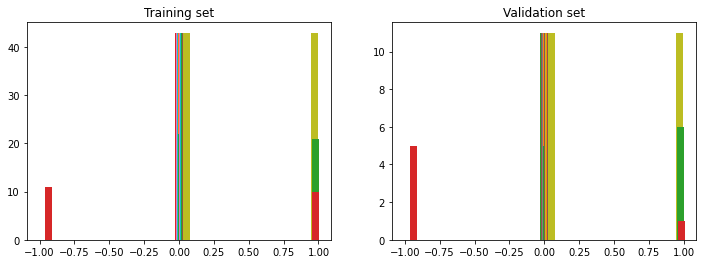

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=num_bins, width=0.05)
axes[0].set_title('Training set')
axes[1].hist(y_valid, bins=num_bins, width=0.05)
axes[1].set_title('Validation set')

We begin the train part

## Train Image part ( 4 Dimensional)

In [33]:
X_image = np.array([df_to_numpy_image(X_train,i) for i in X_train.index])

In [34]:
X_image.shape
#(101, 270, 480, 3)

(43, 270, 480, 3)

In [35]:
#(101, 270, 480, 3)  We choose only the imagen part of the train data, 
#There are 101 picturtes with resolutionn WIDTH = 480 and HEIGHT = 270 with 3 colors rgb

In [36]:
# We perform the reshape

numpy.reshape(a, newshape, order='C')

- a - Array to be reshaped.
- newshape  - The new shape should be compatible with the original shape.

- order- Read the elements of a using this index order, and place the elements into the reshaped array using this index order.

Gives a new shape to an array without changing its data.

In [37]:
WIDTH = 480
HEIGHT = 270

Using arr.reshape() will give a new shape to an array without changing the data. Just remember that when you use the reshape method, the array you want to produce needs to have the same number of elements as the original array.

If you start with an array with N elements, you’ll need to make sure that your new array also has a total of N elements

You can use reshape() to reshape your array. 



![title](np_reshape.png)

With np.reshape, you can specify a few optional parameters:
np.reshape(a, newshape=(d, e), order='C')

a is the array to be reshaped.

newshape is the new shape you want. You can specify an integer or a tuple of integers. If you specify an integer, the result will be an array of that length. The shape should be compatible with the original shape.

order: C means to read/write the elements using C-like index order, F means to read/write the elements using Fortran-like index order, A means to read/write the elements in Fortran-like index order if a is Fortran contiguous in memory, C-like order otherwise. (This is an optional parameter and doesn’t need to be specified.)

If you want to learn more about C and Fortran order, you can read more about the internal organization of NumPy arrays here. Essentially, C and Fortran orders have to do with how indices correspond to the order the array is stored in memory. In Fortran, when moving through the elements of a two-dimensional array as it is stored in memory, the first index is the most rapidly varying index. As the first index moves to the next row as it changes, the matrix is stored one column at a time. This is why Fortran is thought of as a Column-major language. In C on the other hand, the last index changes the most rapidly. The matrix is stored by rows, making it a Row-major language. What you do for C or Fortran depends on whether it’s more important to preserve the indexing convention or not reorder the data.

We will reshape  270, 480 to  480, 270

(101, 270, 480, 3) -> (101, 480, 270, 3)

What does -1 mean in numpy reshape? A numpy matrix can be reshaped into a vector using reshape function with parameter -1. The criterion to satisfy for providing the new shape is that 'The new shape should be compatible with the original shape'

numpy allow us to give one of new shape parameter as -1 (eg: (-1,WIDTH,HEIGHT,3) . It simply means that it is an unknown dimension and we want numpy to figure it out. And numpy will figure this by looking at the 'length of the array and remaining dimensions' and making sure it satisfies the above mentioned criteria

In [38]:
# For cleaned processed rgb
X=X_image.reshape(-1,WIDTH,HEIGHT,3)
X.shape
#(101, 480, 270, 3) # the first number may change between the range (0 ,500)

(43, 480, 270, 3)

In [39]:
X.size

16718400

## Train Input part ( 1 Dimensional )

In [40]:
def df_to_numpy_input(df_input,index): 
    # flattening a 2d numpy array
    # into 1d array
    # and remove dtype at the end of numpy array
    lista=df_input.loc[[index]].values.tolist()
    arr=np.array(lista).ravel()
    return arr


In [41]:
Y = [df_to_numpy_input(y_train,i) for i in y_train.index]

In [42]:
Y[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

In [43]:
type(Y[0])

numpy.ndarray

In [44]:
len(Y)

43

In [45]:
type(Y)

list

We begin the test part

## Test Image part ( 4 Dimensional)

In [46]:
test_image = np.array([df_to_numpy_image(X_valid,i) for i in X_valid.index])

In [47]:
type(test_image)

numpy.ndarray

In [48]:
test_image.ndim

4

In [49]:
test_image.shape
#(26, 270, 480, 3)

(11, 270, 480, 3)

numpy.reshape(a, newshape, order='C')

- a - Array to be reshaped.
- newshape  - The new shape should be compatible with the original shape.

- order- Read the elements of a using this index order, and place the elements into the reshaped array using this index order.

Gives a new shape to an array without changing its data.

In [50]:
#For processed
test_x=test_image.reshape(-1,WIDTH,HEIGHT,3)
test_x.shape
#(26, 480, 270, 3)

(11, 480, 270, 3)

## Test Input part

In [51]:
test_y = [df_to_numpy_input(y_valid,i) for i in y_valid.index]

In [52]:
#FILE_I_END = 1860
FILE_I_END = 2
WIDTH = 480
HEIGHT = 270
LR = 1e-3
#EPOCHS = 30
EPOCHS = 1
MODEL_NAME = 'model_clean/test'
PREV_MODEL = ''
LOAD_MODEL = True

wl = 0
sl = 0
al = 0
dl = 0

wal = 0
wdl = 0
sal = 0
sdl = 0
nkl = 0

w = [1,0,0,0,0,0,0,0,0]
s = [0,1,0,0,0,0,0,0,0]
a = [0,0,1,0,0,0,0,0,0]
d = [0,0,0,1,0,0,0,0,0]
wa = [0,0,0,0,1,0,0,0,0]
wd = [0,0,0,0,0,1,0,0,0]
sa = [0,0,0,0,0,0,1,0,0]
sd = [0,0,0,0,0,0,0,1,0]
nk = [0,0,0,0,0,0,0,0,1]

In [53]:
len(nk )

9

In [54]:
size=[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0]

In [55]:
len(size)

29

In [ ]:
# =============================================================================
# Create PyTorch Model
# =============================================================================

# Model configuration
MODEL_NAME = 'efficientnet_lstm'  # Options: efficientnet_lstm, mobilenet_v3, etc.
NUM_ACTIONS = 29
TEMPORAL_FRAMES = 4

# Training hyperparameters
EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 1e-4

# Paths
MODEL_DIR = Path('model_processed')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}.pth'

# Get model info
model_info = get_model_info(MODEL_NAME)
is_temporal = model_info.get("temporal", False)
seq_len = TEMPORAL_FRAMES if is_temporal else 1

print(f"Creating model: {MODEL_NAME}")
print(f"  Temporal: {is_temporal} (seq_len={seq_len})")

# Create model
model = get_model(
    MODEL_NAME,
    num_actions=NUM_ACTIONS,
    temporal_frames=seq_len,
    pretrained=True
)
model = model.to(device)
print(f"  Parameters: {count_parameters(model):,}")

In [ ]:
# =============================================================================
# PyTorch Training Loop (Simple Version)
# =============================================================================

# Create PyTorch Dataset for processed data
class ProcessedDataset(Dataset):
    """PyTorch Dataset for processed numpy array data."""
    
    def __init__(self, X_images, Y_labels, seq_len=1):
        self.frames = X_images
        self.actions = np.array(Y_labels, dtype=np.float32)
        self.seq_len = seq_len
    
    def __len__(self):
        return max(0, len(self.frames) - self.seq_len + 1)
    
    def __getitem__(self, idx):
        if self.seq_len > 1:
            frames = self.frames[idx:idx + self.seq_len]
        else:
            frames = self.frames[idx:idx + 1]
        action = self.actions[idx + self.seq_len - 1]
        
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2) / 255.0
        if self.seq_len == 1:
            frames = frames.squeeze(0)
        action = torch.tensor(action, dtype=torch.float32)
        return frames, action

# Create datasets
train_dataset = ProcessedDataset(X, Y, seq_len=seq_len)
val_dataset = ProcessedDataset(test_x, test_y, seq_len=seq_len)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

# Train for one epoch
model.train()
total_loss = 0.0
for batch_idx, (frames, actions) in enumerate(train_loader):
    frames = frames.to(device)
    actions = actions.to(device)
    
    optimizer.zero_grad()
    outputs = model(frames)
    loss = criterion(outputs, actions)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    total_loss += loss.item()
    if (batch_idx + 1) % 10 == 0:
        print(f"  Batch {batch_idx + 1}/{len(train_loader)} - Loss: {loss.item():.4f}")

avg_train_loss = total_loss / len(train_loader)

# Validation
model.eval()
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for frames, actions in val_loader:
        frames = frames.to(device)
        actions = actions.to(device)
        
        outputs = model(frames)
        loss = criterion(outputs, actions)
        val_loss += loss.item()
        
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == actions).all(dim=1).sum().item()
        total += actions.size(0)

avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
val_acc = correct / total if total > 0 else 0.0

print(f"\nEpoch Summary:")
print(f"  Train Loss: {avg_train_loss:.4f}")
print(f"  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

In [88]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)

In [ ]:
restartkernel()

## Full code

In [ ]:
# =============================================================================
# Full Code 1 - Training with Processed Data (PyTorch Version)
# =============================================================================

import numpy as np
import cv2
import os
import pandas as pd
from pathlib import Path
from collections import deque
from random import shuffle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import logging, sys
logging.disable(sys.maxsize)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Local imports
from models_pytorch import (
    get_model, list_models, get_model_info, 
    save_model, load_model, count_parameters, get_device
)

# Configuration
FILE_I_END = 1  # Number of data files to use
WIDTH = 480
HEIGHT = 270
EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
MODEL_NAME = 'efficientnet_lstm'
NUM_ACTIONS = 29
MODEL_DIR = Path('model_processed1')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}.pth'
LOAD_MODEL = False

# Device setup
device = get_device()
print(f"Using device: {device}")

# PyTorch Dataset
class ProcessedDataset(Dataset):
    def __init__(self, X_images, Y_labels, seq_len=1):
        self.frames = X_images
        self.actions = np.array(Y_labels, dtype=np.float32)
        self.seq_len = seq_len
    
    def __len__(self):
        return max(0, len(self.frames) - self.seq_len + 1)
    
    def __getitem__(self, idx):
        if self.seq_len > 1:
            frames = self.frames[idx:idx + self.seq_len]
        else:
            frames = self.frames[idx:idx + 1]
        action = self.actions[idx + self.seq_len - 1]
        
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2) / 255.0
        if self.seq_len == 1:
            frames = frames.squeeze(0)
        action = torch.tensor(action, dtype=torch.float32)
        return frames, action

def cleaning_data(train_data, show=False):
    """Clean and balance the training data."""
    df = pd.DataFrame()
    for i in range(len(train_data)):
        row = list(train_data[i][1])
        temp = pd.DataFrame([row])
        df = pd.concat([df, temp])
    df = df.reset_index(drop=True)

    num_bins = 25
    threshold = (df[13] != 0).astype(int).sum(axis=0)
    samples_per_bin = threshold
    hist, bins = np.histogram(df[13], num_bins)
    center = (bins[:-1] + bins[1:]) * 0.5
    
    remove_list = []
    for j in range(num_bins):
        list_ = []
        for i in range(len(df[13])):
            serie = df[13].iloc[[i]]
            ls = serie.tolist()
            if ls[0] >= bins[j] and ls[0] <= bins[j+1]:
                list_.append(i)      
        list_ = list_[samples_per_bin:]
        remove_list.extend(list_)
        
    df.drop(df.index[remove_list], inplace=True)
    print('remaining:', len(df))
    df = df.reset_index(drop=True)
    
    if show:
        hist, _ = np.histogram(df[13], (num_bins))
        plt.bar(center, hist, width=0.05)
        plt.plot((np.min(df[13]), np.max(df[13])), (samples_per_bin, samples_per_bin))
    
    df_image = pd.DataFrame()
    for i in range(len(train_data)):
        row = list(train_data[i][0])
        temp = pd.DataFrame([row])
        df_image = pd.concat([df_image, temp])
    df_image = df_image.reset_index(drop=True)
    df_image_removed = df_image.drop(remove_list, axis=0, inplace=False)
    df_image_clean = df_image_removed.reset_index(drop=True)
    
    assert len(df) == len(df_image_clean), "Dimensions mismatch"
    return df_image_clean, df

# Get model info
model_info = get_model_info(MODEL_NAME)
is_temporal = model_info.get("temporal", False)
seq_len = 4 if is_temporal else 1

# Create model
print(f"Creating model: {MODEL_NAME}")
model = get_model(MODEL_NAME, num_actions=NUM_ACTIONS, temporal_frames=seq_len, pretrained=True)
model = model.to(device)
print(f"Parameters: {count_parameters(model):,}")

if LOAD_MODEL and MODEL_PATH.exists():
    model, _ = load_model(str(MODEL_PATH), device=device)
    print('Loaded previous model!')

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS * FILE_I_END)
criterion = nn.BCEWithLogitsLoss()

# Training loop
for e in range(EPOCHS):
    data_order = [i for i in range(1, FILE_I_END + 1)]
    shuffle(data_order)
    
    for count, i in enumerate(data_order):
        try:
            file_name = f'preprocessed_training_data-{i}.npy'
            print(f"Loading {file_name}...")
            train_data = np.load(file_name, allow_pickle=True)
            
            # Clean the data
            df_image_clean, df = cleaning_data(train_data, show=False)
            
            # Prepare arrays
            X_image = np.array([df_image_clean.loc[[idx]].T.to_numpy().flatten() 
                               for idx in df_image_clean.index])
            X = X_image.reshape(-1, WIDTH, HEIGHT, 3)
            Y = [df.loc[[idx]].values.ravel() for idx in df.index]
            
            # Split
            X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=6)
            
            # Create dataloaders
            train_dataset = ProcessedDataset(X_train, Y_train, seq_len=seq_len)
            val_dataset = ProcessedDataset(X_val, Y_val, seq_len=seq_len)
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
            
            # Train
            model.train()
            total_loss = 0.0
            for frames, actions in train_loader:
                frames, actions = frames.to(device), actions.to(device)
                optimizer.zero_grad()
                outputs = model(frames)
                loss = criterion(outputs, actions)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
            
            # Validate
            model.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for frames, actions in val_loader:
                    frames, actions = frames.to(device), actions.to(device)
                    outputs = model(frames)
                    loss = criterion(outputs, actions)
                    val_loss += loss.item()
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                    correct += (preds == actions).all(dim=1).sum().item()
                    total += actions.size(0)
            
            avg_train = total_loss / len(train_loader) if len(train_loader) > 0 else 0
            avg_val = val_loss / len(val_loader) if len(val_loader) > 0 else 0
            val_acc = correct / total if total > 0 else 0
            
            print(f"File {i} - Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}, Val Acc: {val_acc:.4f}")
            
            scheduler.step()
            
            if count % 10 == 0:
                print('SAVING MODEL!')
                save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=e)
                
        except Exception as ex:
            print(f"Error: {str(ex)}")

print("\nTraining complete!")
save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=EPOCHS-1)

## TensorBoard in Terminal

In [9]:
#pip install tensorboard

After the learning step has completed, you can just open a terminal and enter the command below
$ tensorboard --logdir='/tmp/tflearn_logs'

tensorboard --logdir='/log/model_clean/test'

I have to be sure that model = tflearn.DNN(network, checkpoint_path='/tmp/tflearn_logs/',max_checkpoints=1, tensorboard_verbose=0) By adjusting tensorboard_variable, we tell  Tflearn to save metrics that Tensorboard will master later.


## TensorBoard in Jupyter Notebook

TensorBoard is a great tool providing visualization of many metrics necessary to evaluate TensorFlow model training. It used to be difficult to bring up this tool especially in a hosted Jupyter Notebook environment such as Google Colab, Kaggle notebook and Coursera's Notebook etc. 

Start by installing TF 2.0 and loading the TensorBoard notebook extension:

In [12]:
#!pip install -q tf-nightly


In [1]:
import tensorflow as tf
import datetime, os

In [2]:
MODEL_NAME = 'model_clean/test'

In [6]:
#pip install tensorboard

In [7]:
#pip uninstall tensorboard

In [ ]:
#pip install tf-nightly

In [8]:
#pip uninstall tf-nightly

In [9]:
#pip install --force-reinstall tf-nightly

In [ ]:
# Load the TensorBoard notebook extension

In [11]:
%load_ext tensorboard
%tensorboard --logdir log

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 13816), started 0:01:30 ago. (Use '!kill 13816' to kill it.)

In [ ]:
# =============================================================================
# Full Code 2 - Multi-File Training Setup (PyTorch Version)
# =============================================================================

import numpy as np
import cv2
import os
import pandas as pd
from pathlib import Path
from collections import deque
from random import shuffle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import logging, sys
logging.disable(sys.maxsize)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Local imports
from models_pytorch import (
    get_model, list_models, get_model_info, 
    save_model, load_model, count_parameters, get_device
)

# Configuration
FILE_I_END = 30  # Number of data files
WIDTH = 480
HEIGHT = 270
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
MODEL_NAME = 'efficientnet_lstm'
NUM_ACTIONS = 29
MODEL_DIR = Path('model_processed2')
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / f'{MODEL_NAME}.pth'
LOAD_MODEL = False

# Device setup
device = get_device()
print(f"Using device: {device}")

# PyTorch Dataset
class ProcessedDataset(Dataset):
    def __init__(self, X_images, Y_labels, seq_len=1):
        self.frames = X_images
        self.actions = np.array(Y_labels, dtype=np.float32)
        self.seq_len = seq_len
    
    def __len__(self):
        return max(0, len(self.frames) - self.seq_len + 1)
    
    def __getitem__(self, idx):
        if self.seq_len > 1:
            frames = self.frames[idx:idx + self.seq_len]
        else:
            frames = self.frames[idx:idx + 1]
        action = self.actions[idx + self.seq_len - 1]
        
        frames = torch.tensor(frames, dtype=torch.float32)
        frames = frames.permute(0, 3, 1, 2) / 255.0
        if self.seq_len == 1:
            frames = frames.squeeze(0)
        action = torch.tensor(action, dtype=torch.float32)
        return frames, action

def cleaning_data(train_data, show=False):
    """Clean and balance the training data."""
    df = pd.DataFrame()
    for i in range(len(train_data)):
        row = list(train_data[i][1])
        temp = pd.DataFrame([row])
        df = pd.concat([df, temp])
    df = df.reset_index(drop=True)

    num_bins = 25
    threshold = (df[13] != 0).astype(int).sum(axis=0)
    samples_per_bin = threshold
    hist, bins = np.histogram(df[13], num_bins)
    center = (bins[:-1] + bins[1:]) * 0.5
    
    remove_list = []
    for j in range(num_bins):
        list_ = []
        for i in range(len(df[13])):
            serie = df[13].iloc[[i]]
            ls = serie.tolist()
            if ls[0] >= bins[j] and ls[0] <= bins[j+1]:
                list_.append(i)      
        list_ = list_[samples_per_bin:]
        remove_list.extend(list_)
        
    df.drop(df.index[remove_list], inplace=True)
    print('remaining:', len(df))
    df = df.reset_index(drop=True)
    
    if show:
        hist, _ = np.histogram(df[13], (num_bins))
        plt.bar(center, hist, width=0.05)
        plt.plot((np.min(df[13]), np.max(df[13])), (samples_per_bin, samples_per_bin))
    
    df_image = pd.DataFrame()
    for i in range(len(train_data)):
        row = list(train_data[i][0])
        temp = pd.DataFrame([row])
        df_image = pd.concat([df_image, temp])
    df_image = df_image.reset_index(drop=True)
    df_image_removed = df_image.drop(remove_list, axis=0, inplace=False)
    df_image_clean = df_image_removed.reset_index(drop=True)
    
    assert len(df) == len(df_image_clean), "Dimensions mismatch"
    return df_image_clean, df

# Get model info
model_info = get_model_info(MODEL_NAME)
is_temporal = model_info.get("temporal", False)
seq_len = 4 if is_temporal else 1

# Create model
print(f"Creating model: {MODEL_NAME}")
model = get_model(MODEL_NAME, num_actions=NUM_ACTIONS, temporal_frames=seq_len, pretrained=True)
model = model.to(device)
print(f"Parameters: {count_parameters(model):,}")

if LOAD_MODEL and MODEL_PATH.exists():
    model, _ = load_model(str(MODEL_PATH), device=device)
    print('Loaded previous model!')

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS * FILE_I_END)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
def train_model():
    """Train the model on multiple data files."""
    global model, optimizer, scheduler
    
    for e in range(EPOCHS):
        print(f"\n{'='*60}")
        print(f"Epoch {e+1}/{EPOCHS}")
        print(f"{'='*60}")
        
        data_order = [i for i in range(1, FILE_I_END + 1)]
        shuffle(data_order)
        
        for count, i in enumerate(data_order):
            try:
                file_name = f'preprocessed_training_data-{i}.npy'
                train_data = np.load(file_name, allow_pickle=True)
                
                # Clean the data
                df_image_clean, df = cleaning_data(train_data, show=False)
                
                # Prepare arrays
                X_image = np.array([df_image_clean.loc[[idx]].T.to_numpy().flatten() 
                                   for idx in df_image_clean.index])
                X = X_image.reshape(-1, WIDTH, HEIGHT, 3)
                Y = [df.loc[[idx]].values.ravel() for idx in df.index]
                
                # Split
                X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=6)
                
                # Create dataloaders
                train_dataset = ProcessedDataset(X_train, Y_train, seq_len=seq_len)
                val_dataset = ProcessedDataset(X_val, Y_val, seq_len=seq_len)
                train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
                val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
                
                # Train
                model.train()
                total_loss = 0.0
                for frames, actions in train_loader:
                    frames, actions = frames.to(device), actions.to(device)
                    optimizer.zero_grad()
                    outputs = model(frames)
                    loss = criterion(outputs, actions)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    total_loss += loss.item()
                
                # Validate
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0
                with torch.no_grad():
                    for frames, actions in val_loader:
                        frames, actions = frames.to(device), actions.to(device)
                        outputs = model(frames)
                        loss = criterion(outputs, actions)
                        val_loss += loss.item()
                        preds = (torch.sigmoid(outputs) > 0.5).float()
                        correct += (preds == actions).all(dim=1).sum().item()
                        total += actions.size(0)
                
                avg_train = total_loss / len(train_loader) if len(train_loader) > 0 else 0
                avg_val = val_loss / len(val_loader) if len(val_loader) > 0 else 0
                val_acc = correct / total if total > 0 else 0
                
                print(f"  File {i:2d} - Train: {avg_train:.4f}, Val: {avg_val:.4f}, Acc: {val_acc:.4f}")
                
                scheduler.step()
                
                if count % 10 == 0:
                    print('  SAVING MODEL!')
                    save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=e)
                    
            except Exception as ex:
                print(f"  Error with file {i}: {str(ex)}")
    
    print("\nTraining complete!")
    save_model(model, str(MODEL_PATH), optimizer=optimizer, epoch=EPOCHS-1)

# Run training
train_model()

In [16]:
train_model()

remaining: 52
---------------------------------
Run id: model_01/model
Log directory: log/
INFO:tensorflow:Summary name Accuracy/ (raw) is illegal; using Accuracy/__raw_ instead.
---------------------------------
Training samples: 41
Validation samples: 11
--
Training Step: 1  | time: 14.936s
| Momentum | epoch: 001 | loss: 0.00000 - acc: 0.0000 | val_loss: 8.64913 - val_acc: 0.0000 -- iter: 41/41
--
SAVING MODEL!
INFO:tensorflow:C:\Users\rusla\Dropbox\23-GITHUB\Projects\BOT-MMORPG-WITH-AI\versions\0.01\model_01\model is not in all_model_checkpoint_paths. Manually adding it.
INFO:tensorflow:C:\Users\rusla\Dropbox\23-GITHUB\Projects\BOT-MMORPG-WITH-AI\versions\0.01\model_01\model.data-00000-of-00001
INFO:tensorflow:79900
INFO:tensorflow:C:\Users\rusla\Dropbox\23-GITHUB\Projects\BOT-MMORPG-WITH-AI\versions\0.01\model_01\model.index
INFO:tensorflow:79900
INFO:tensorflow:C:\Users\rusla\Dropbox\23-GITHUB\Projects\BOT-MMORPG-WITH-AI\versions\0.01\model_01\model.meta
INFO:tensorflow:80900
rem

Training Step: 17  | total loss: 2.53207 | time: 3.160s
| Momentum | epoch: 017 | loss: 2.53207 - acc: 0.6328 | val_loss: -1.06054 - val_acc: 0.0000 -- iter: 41/41
--
remaining: 52
---------------------------------
Run id: model_01/model
Log directory: log/
---------------------------------
Training samples: 41
Validation samples: 11
--
Training Step: 18  | total loss: 1.13942 | time: 2.949s
| Momentum | epoch: 018 | loss: 1.13942 - acc: 0.5320 | val_loss: 4.62228 - val_acc: 0.0000 -- iter: 41/41
--
remaining: 68
---------------------------------
Run id: model_01/model
Log directory: log/
---------------------------------
Training samples: 54
Validation samples: 14
--
Training Step: 19  | total loss: 1.89153 | time: 3.207s
| Momentum | epoch: 019 | loss: 1.89153 - acc: 0.5010 | val_loss: 2.03180 - val_acc: 1.0000 -- iter: 54/54
--
remaining: 54
---------------------------------
Run id: model_01/model
Log directory: log/
---------------------------------
Training samples: 43
Validation 

In [18]:
%load_ext tensorboard
%tensorboard --logdir log

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 10332), started 0:00:06 ago. (Use '!kill 10332' to kill it.)

The same TensorBoard backend is reused by issuing the same command. If a different logs directory was chosen, a new instance of TensorBoard would be opened. Ports are managed automatically.

Any new interesting feature worth mentioning is the "conceptual graph". To see the conceptual graph, select the “keras” tag. For this example, you’ll see a collapsed Sequential node. Double-click the node to see the model’s structure:

## Alternative Approaches
In this notebook we have used InceptionV3, however it is possible use differnet available  popular neural networks.
Taking into account Keras, In deep learning models there are some applications available alongside pre-trained weights. These models can be used for prediction, feature extraction, and fine-tuning.

Weights are downloaded automatically when instantiating a model. They are stored at ~/.keras/models/.

Upon instantiation, the models will be built according to the image data format set in your Keras configuration file at ~/.keras/keras.json. For instance, if you have set image_data_format=channels_last, then any model loaded from this repository will get built according to the TensorFlow data format convention, "Height-Width-Depth".

Available models
Model	Size (MB)	Top-1 Accuracy	Top-5 Accuracy	Parameters	Depth	Time (ms) per inference step (CPU)	Time (ms) per inference step (GPU)
- Xception	88	79.0%	94.5%	22.9M	81	109.4	8.1
- VGG16	528	71.3%	90.1%	138.4M	16	69.5	4.2
- VGG19	549	71.3%	90.0%	143.7M	19	84.8	4.4
- ResNet50	98	74.9%	92.1%	25.6M	107	58.2	4.6
- ResNet50V2	98	76.0%	93.0%	25.6M	103	45.6	4.4
- ResNet101	171	76.4%	92.8%	44.7M	209	89.6	5.2
- ResNet101V2	171	77.2%	93.8%	44.7M	205	72.7	5.4
- ResNet152	232	76.6%	93.1%	60.4M	311	127.4	6.5
- ResNet152V2	232	78.0%	94.2%	60.4M	307	107.5	6.6
- InceptionV3	92	77.9%	93.7%	23.9M	189	42.2	6.9

# ConvNet Network

In [19]:
import tensorflow as tf

In [ ]:
# =============================================================================
# Alternative: Quick Model Test (PyTorch)
# =============================================================================

# Create a fresh model for testing
test_model = get_model(MODEL_NAME, num_actions=NUM_ACTIONS, temporal_frames=seq_len, pretrained=True)
test_model = test_model.to(device)
print(f"Test model created: {MODEL_NAME}")
print(f"Parameters: {count_parameters(test_model):,}")

# List all available models
print("\nAvailable models:")
for name in list_models():
    info = get_model_info(name)
    rec = " [RECOMMENDED]" if info.get("recommended") else ""
    print(f"  {name}{rec} - {info['params']}")

In [41]:
model = resnext(WIDTH, HEIGHT, 3, LR, output=29, model_name=MODEL_NAME)

NameError: name 'n' is not defined

In [40]:
import tflearn
from tflearn.layers.conv import conv_2d, max_pool_2d,avg_pool_2d, conv_3d, max_pool_3d, avg_pool_3d
from tflearn.layers.core import input_data, dropout, fully_connected
from tflearn.layers.estimator import regression
from tflearn.layers.normalization import local_response_normalization
from tflearn.layers.merge_ops import merge

In [39]:
def resnext(width, height, frame_count, lr, output=9, model_name = 'sentnet_color.model'):
    net = input_data(shape=[None, width, height, 3], name='input')
    net = tflearn.conv_2d(net, 16, 3, regularizer='L2', weight_decay=0.0001)
    net = tflearn.layers.conv.resnext_block(net, n, 16, 32)
    net = tflearn.resnext_block(net, 1, 32, 32, downsample=True)
    net = tflearn.resnext_block(net, n-1, 32, 32)
    net = tflearn.resnext_block(net, 1, 64, 32, downsample=True)
    net = tflearn.resnext_block(net, n-1, 64, 32)
    net = tflearn.batch_normalization(net)
    net = tflearn.activation(net, 'relu')
    net = tflearn.global_avg_pool(net)
    # Regression
    net = tflearn.fully_connected(net, output, activation='softmax')
    opt = tflearn.Momentum(0.1, lr_decay=0.1, decay_step=32000, staircase=True)
    net = tflearn.regression(net, optimizer=opt,
                             loss='categorical_crossentropy')

    model = tflearn.DNN(net,
                        max_checkpoints=0, tensorboard_verbose=0, tensorboard_dir='log')

    return model